# Week 13 — Google Earth Engine & Cloud-Scale Time Series
## ARIA v9.0 — Student Exercise Notebook (學生練習版)

**Course (課程):** Remote Sensing and Spatial Information Analysis and Applications
**Theme (主題):** Cloud-based satellite time-series analysis with Google Earth Engine
**Study Area (研究區域):** Hualien, Taiwan (花蓮) — Post-earthquake (2024/04/03) & landslide dam (堰塞湖) analysis
**Bounding Box:** `[121.2574, 23.6546, 121.4984, 23.7447]`

---

### Learning Objectives (學習目標)
1. Access and filter large satellite archives via GEE Python API
2. Compute NDVI time series and detect vegetation change after an earthquake
3. Integrate optical (Sentinel-2) and SAR (Sentinel-1) observations
4. Create pre/post composites and compute change maps
5. Export cloud-computed products for local analysis

### How to Use This Notebook (使用說明)
- Cells marked **COMPLETE** are ready to run — do not modify them.
- Cells with `# TODO:` require you to **fill in the blanks** before running.
- `# HINT:` comments provide guidance for each exercise.
- Run cells **in order** from top to bottom.

### Prerequisites (先備知識)
- W8: NDVI fundamentals — W9: Change detection — W10: SAR basics — W12: Classification

> **Student Exercise Notebook (學生練習筆記本)** — fill in the blanks and run.

---
## S1 — Environment Setup (環境設定) ✅ COMPLETE

Install and import the required packages. We authenticate with Google Earth Engine,
set up Chinese font rendering for matplotlib, define our Area of Interest (AOI),
and run a quick connectivity test.

> **Note:** You need a GEE-enabled Google Cloud project. Replace `'your-project-id'`
> with your actual project ID.

This cell is **complete** — just run it.

In [1]:
# ============================================================
# S1 — Environment Setup (環境設定) — COMPLETE
# ============================================================
import warnings
warnings.filterwarnings('ignore')

# --- Core imports ---
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import os, platform

# --- GEE Authentication & Initialization ---
# Already authenticated via terminal (earthengine authenticate --auth_mode=notebook)
# Re-authenticate only if needed (e.g. switching Google account):
# ee.Authenticate()
ee.Initialize(project='rs-496806')

# --- Chinese font setup (跨平台中文字型) ---
from matplotlib import font_manager as fm

def setup_chinese_font():
    """Cross-platform Chinese font configuration."""
    system = platform.system()
    candidates = {
        'Windows': ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei'],
        'Darwin':  ['PingFang TC', 'Heiti TC', 'STHeiti'],
        'Linux':   ['Noto Sans CJK TC', 'WenQuanYi Micro Hei',
                    'AR PL UMing TW', 'Noto Sans TC']
    }
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates.get(system, candidates['Linux']):
        if name in available:
            plt.rcParams['font.sans-serif'] = [name] + plt.rcParams['font.sans-serif']
            plt.rcParams['axes.unicode_minus'] = False
            print(f"  Chinese font set to: {name}")
            return name
    # Fallback: try all candidates
    for flist in candidates.values():
        for name in flist:
            if name in available:
                plt.rcParams['font.sans-serif'] = [name] + plt.rcParams['font.sans-serif']
                plt.rcParams['axes.unicode_minus'] = False
                print(f"  Chinese font (fallback) set to: {name}")
                return name
    print("  WARNING: No CJK font found — Chinese text may not render correctly.")
    return None

font_name = setup_chinese_font()

# --- Define AOI (定義研究區域) ---
HUALIEN_BBOX = [121.2574, 23.6546, 121.4984, 23.7447]
aoi = ee.Geometry.Rectangle(HUALIEN_BBOX)

# --- Quick connectivity test (連線測試) ---
point = ee.Geometry.Point([121.37, 23.70])
elev = ee.Image('USGS/SRTMGL1_003').sample(point, 30).first().get('elevation').getInfo()
print(f"  Connectivity OK — Elevation at test point: {elev} m")

print()
print("=" * 60)
print("  S1 COMPLETE — Environment ready")
print(f"  AOI: {HUALIEN_BBOX}")
print(f"  Platform: {platform.system()} / Python {platform.python_version()}")
print("=" * 60)

  Chinese font set to: Microsoft JhengHei
  Connectivity OK — Elevation at test point: 1009 m

  S1 COMPLETE — Environment ready
  AOI: [121.2574, 23.6546, 121.4984, 23.7447]
  Platform: Windows / Python 3.10.20


---
## S2 — Filter Sentinel-2 ImageCollection (Sentinel-2 影像集篩選) ✏️ EXERCISE

We access the **Sentinel-2 Level-2A Surface Reflectance (Harmonized)** collection
and filter it by:
- **Date range (日期範圍):** 2020-01-01 to 2026-03-31
- **Cloud cover (雲量):** less than 40%
- **Spatial bounds (空間範圍):** our Hualien AOI

### Key GEE Concepts (關鍵概念)
- `ee.ImageCollection` — a stack of images managed on the server
- `filterDate(start, end)` — keep only images within a date range
- `filterBounds(geometry)` — keep only images that overlap our AOI
- `filter(ee.Filter.lt(property, value))` — filter by metadata property

> **HINT:** See Pre-lab Step 4 for ImageCollection filtering concepts.

In [2]:
# ============================================================
# S2 — Filter Sentinel-2 ImageCollection — COMPLETED
# ============================================================

s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          # Filter by date range — 2020-01-01 to 2026-03-31
          .filterDate('2020-01-01', '2026-03-31')
          # Filter by cloud cover — keep images with CLOUDY_PIXEL_PERCENTAGE < 40
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
          .filterBounds(aoi))

# --- Collection statistics (do not modify below) ---
count = s2_col.size().getInfo()
print(f"  Total Sentinel-2 images (2020-2026, cloud < 40%): {count}")

# Date range
dates = s2_col.aggregate_array('system:time_start').getInfo()
dates_dt = [datetime.utcfromtimestamp(d / 1000) for d in dates]
print(f"  Date range: {min(dates_dt).strftime('%Y-%m-%d')} -> {max(dates_dt).strftime('%Y-%m-%d')}")

# Cloud cover stats
cloud_stats = s2_col.aggregate_stats('CLOUDY_PIXEL_PERCENTAGE').getInfo()
print(f"  Cloud cover — mean: {cloud_stats['mean']:.1f}%, "
      f"min: {cloud_stats['min']:.1f}%, max: {cloud_stats['max']:.1f}%")

# --- Display first image as RGB ---
first_img = s2_col.sort('system:time_start').first()
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}

Map2 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map2.addLayer(first_img.clip(aoi), vis_rgb, 'First S2 Image (RGB)')
Map2.addLayer(aoi, {'color': 'red'}, 'AOI — Hualien')
Map2

  Total Sentinel-2 images (2020-2026, cloud < 40%): 143
  Date range: 2020-01-11 -> 2026-03-30
  Cloud cover — mean: 20.7%, min: 0.0%, max: 39.5%


Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## S3 — NDVI Calculation + Cloud Masking (NDVI 計算與雲遮罩) ✏️ EXERCISE

Sentinel-2 Level-2A includes a **Scene Classification Layer (SCL)** band.
We use SCL to mask clouds, cloud shadows, snow, and other unwanted pixels.

| SCL Value | Class             | Keep? |
|-----------|-------------------|-------|
| 4         | Vegetation        | Yes   |
| 5         | Bare soil         | Yes   |
| 6         | Water             | Yes   |
| 7         | Unclassified      | Yes   |
| 3, 8, 9, 10, 11 | Cloud/shadow/snow | No |

**NDVI = (NIR - Red) / (NIR + Red) = (B8 - B4) / (B8 + B4)**

> **HINT:** B8 = NIR, B4 = Red — same as W8. The `normalizedDifference` function
> takes `['NIR_band', 'Red_band']` in that order.

In [3]:
# ============================================================
# S3 — NDVI Calculation + Cloud Masking — COMPLETED
# ============================================================

def mask_and_ndvi(image):
    """Apply SCL cloud mask and compute NDVI for a single S2 image."""
    scl = image.select('SCL')

    # Keep good pixels: vegetation(4), bare soil(5), water(6), unclassified(7)
    good_mask = (scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7)))

    # NDVI = (NIR - Red) / (NIR + Red) = (B8 - B4) / (B8 + B4)
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    return (image.addBands(ndvi)
            .updateMask(good_mask)
            .copyProperties(image, ['system:time_start']))

# Apply to entire collection
ndvi_col = s2_col.map(mask_and_ndvi)

# --- Display a sample NDVI image (do not modify below) ---
sample_img = ndvi_col.sort('system:time_start').first()
vis_ndvi = {'bands': ['NDVI'], 'min': 0, 'max': 0.8,
            'palette': ['red', 'yellow', 'green', 'darkgreen']}

Map3 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map3.addLayer(sample_img.select('NDVI').clip(aoi), vis_ndvi, 'Sample NDVI')
Map3.addLayer(aoi, {'color': 'red'}, 'AOI')
Map3

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## S4 — Monthly NDVI Time Series with Spatial Spread (月均 NDVI 時間序列 + 空間分布) ✏️ EXERCISE

We aggregate NDVI to monthly medians, then retrieve **three spatial statistics**
over our AOI: the **mean** (regional average), **min** (worst pixel), and
**max** (best pixel).

### Why Three Lines Instead of One? (為什麼需要三條線？)

Imagine a classroom of 30 students taking an exam. If the class average is 75,
you might think "the class did OK." But what if the range is 20 to 100?
That tells a very different story — some students excelled, others struggled.

The same logic applies to satellite pixels:
- **Mean** = class average (overall health of the region)
- **Min** = lowest-scoring student (worst-damaged pixel — a landslide scar?)
- **Max** = top student (healthiest forest pixel — undamaged reference)

**Your tasks:**
1. Run the provided function to compute monthly mean/min/max
2. Create the matplotlib time series plot with a **shaded band** between min and max
3. Add the earthquake marker on 2024-04-03
4. Answer the guided scientific inquiry questions below

> The earthquake struck on **2024-04-03** — does the min value reveal damage
> signals that the mean alone might miss?


In [4]:
# ============================================================
# S4 — Monthly NDVI Time Series with Spatial Spread — PARTIALLY COMPLETE
# ============================================================

# --- This function is COMPLETE — do not modify ---
def compute_monthly_ndvi(ndvi_collection, aoi, start_year=2020, end_year=2026):
    """Compute monthly NDVI statistics (mean, min, max) over an AOI.
    Returns a list of (date, mean, min, max) tuples.
    """
    results = []

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            start = f'{year}-{month:02d}-01'
            if month == 12:
                end = f'{year + 1}-01-01'
            else:
                end = f'{year}-{month + 1:02d}-01'

            monthly = ndvi_collection.filterDate(start, end).select('NDVI')
            n = monthly.size().getInfo()

            if n == 0:
                results.append((datetime(year, month, 15), None, None, None))
                continue

            median_img = monthly.median()
            stats = median_img.reduceRegion(
                reducer=ee.Reducer.mean()
                    .combine(ee.Reducer.min(), sharedInputs=True)
                    .combine(ee.Reducer.max(), sharedInputs=True),
                geometry=aoi,
                scale=100,
                maxPixels=1e8
            ).getInfo()

            v_mean = stats.get('NDVI_mean')
            v_min  = stats.get('NDVI_min')
            v_max  = stats.get('NDVI_max')
            results.append((datetime(year, month, 15), v_mean, v_min, v_max))

            if v_mean is not None:
                print(f'  {start[:7]}: mean={v_mean:.3f}  min={v_min:.3f}  '
                      f'max={v_max:.3f}  (n={n})')
            else:
                print(f'  {start[:7]}: no data  (n={n})')

    return results

print('Computing monthly NDVI with spatial statistics...')
print('(mean = regional average, min = worst pixel, max = best pixel)')
print()
monthly_data = compute_monthly_ndvi(ndvi_col, aoi)

# --- Prepare data for plotting (do not modify) ---
dates_plot  = [d for d, m, mn, mx in monthly_data if m is not None]
mean_plot   = [m for d, m, mn, mx in monthly_data if m is not None]
min_plot    = [mn for d, m, mn, mx in monthly_data if m is not None]
max_plot    = [mx for d, m, mn, mx in monthly_data if m is not None]


Computing monthly NDVI with spatial statistics...
(mean = regional average, min = worst pixel, max = best pixel)

  2020-01: mean=0.706  min=-0.355  max=0.997  (n=3)
  2020-02: mean=0.695  min=-0.231  max=0.922  (n=2)
  2020-03: mean=0.630  min=-0.041  max=0.895  (n=1)
  2020-04: mean=0.659  min=-0.070  max=0.900  (n=1)
  2020-05: mean=0.639  min=-0.112  max=0.951  (n=2)
  2020-06: mean=0.752  min=-0.159  max=0.955  (n=3)
  2020-07: mean=0.709  min=-0.069  max=0.941  (n=2)
  2020-08: mean=0.716  min=-0.100  max=0.940  (n=2)
  2020-09: mean=0.635  min=-0.057  max=0.926  (n=2)
  2020-10: mean=0.698  min=-0.131  max=0.933  (n=2)
  2020-11: mean=0.755  min=-0.229  max=0.954  (n=3)
  2020-12: mean=0.698  min=-0.133  max=0.935  (n=1)
  2021-01: mean=0.711  min=-0.149  max=0.996  (n=3)
  2021-02: mean=0.625  min=-0.081  max=0.891  (n=3)
  2021-03: mean=0.692  min=-0.094  max=0.921  (n=3)
  2021-04: mean=0.724  min=-0.129  max=0.964  (n=2)
  2021-05: mean=0.716  min=-0.115  max=0.993  (n=3)
  

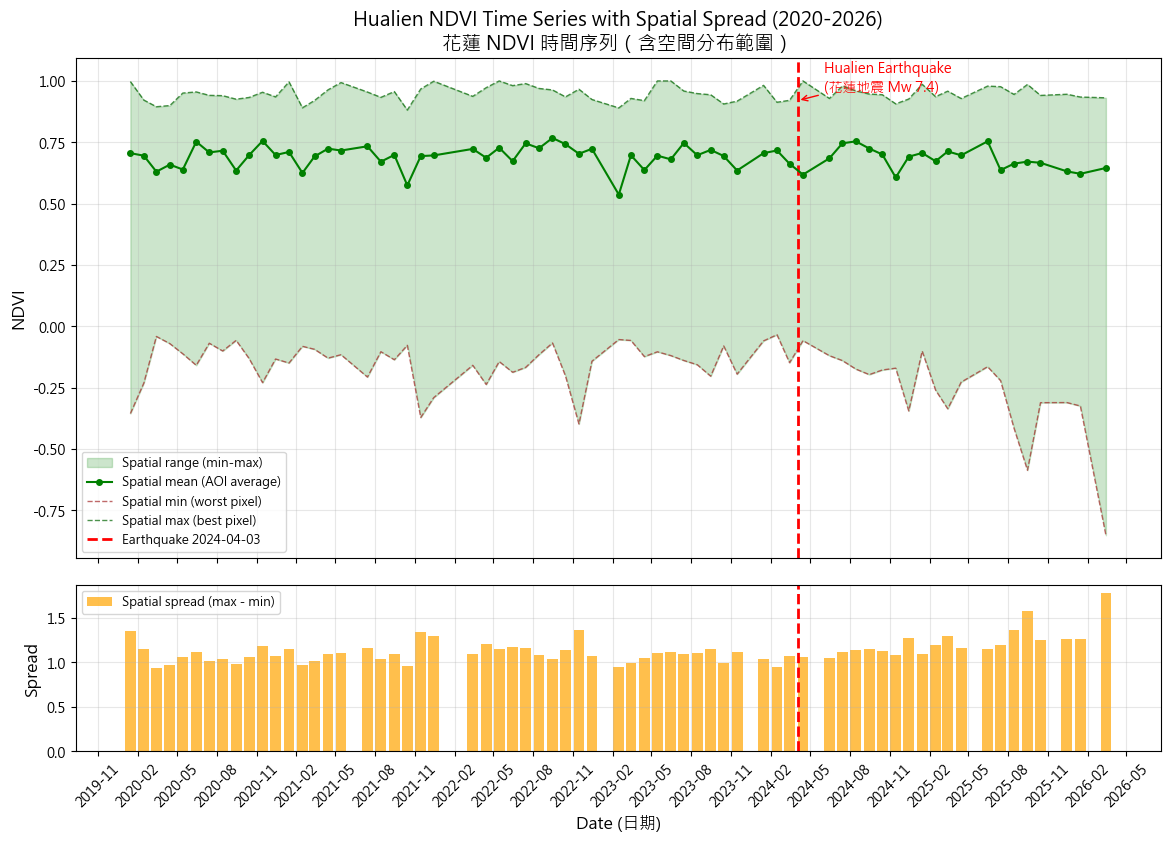

  Pre-earthquake  avg spread: 1.0936
  Post-earthquake avg spread: 1.2264


In [5]:
# ============================================================
# S4 (continued) — Plot NDVI Time Series with Spread — COMPLETED
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1],
                         sharex=True, gridspec_kw={'hspace': 0.08})

# --- Upper panel: NDVI time series with min-max band ---
ax = axes[0]

# Shaded band between min and max (spatial spread)
ax.fill_between(dates_plot, min_plot, max_plot,
                alpha=0.2, color='green', label='Spatial range (min-max)')

# Plot mean, min, max lines (complete)
ax.plot(dates_plot, mean_plot, 'o-', color='green', markersize=4, linewidth=1.5,
        label='Spatial mean (AOI average)', zorder=3)
ax.plot(dates_plot, min_plot, '--', color='brown', linewidth=1, alpha=0.7,
        label='Spatial min (worst pixel)')
ax.plot(dates_plot, max_plot, '--', color='darkgreen', linewidth=1, alpha=0.7,
        label='Spatial max (best pixel)')

# Earthquake marker (vertical dashed red line)
eq_date = datetime(2024, 4, 3)
ax.axvline(eq_date, color='red', linestyle='--', linewidth=2,
           label='Earthquake 2024-04-03')
ax.annotate('Hualien Earthquake\n(花蓮地震 Mw 7.4)',
            xy=(eq_date, max(max_plot) * 0.92),
            xytext=(eq_date + timedelta(days=60), max(max_plot) * 0.96),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Hualien NDVI Time Series with Spatial Spread (2020-2026)\n'
             '花蓮 NDVI 時間序列（含空間分布範圍）', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Lower panel: Spread (max - min) ---
ax2 = axes[1]
spread_plot = [mx - mn for mn, mx in zip(min_plot, max_plot)]
ax2.bar(dates_plot, spread_plot, width=25, color='orange', alpha=0.7,
        label='Spatial spread (max - min)')
ax2.axvline(eq_date, color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Spread', fontsize=12)
ax2.set_xlabel('Date (日期)', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Summary statistics ---
pre_spreads = [mx - mn for d, m, mn, mx in monthly_data
               if m is not None and d < eq_date]
post_spreads = [mx - mn for d, m, mn, mx in monthly_data
                if m is not None and d >= eq_date]
if pre_spreads and post_spreads:
    print(f'  Pre-earthquake  avg spread: {sum(pre_spreads)/len(pre_spreads):.4f}')
    print(f'  Post-earthquake avg spread: {sum(post_spreads)/len(post_spreads):.4f}')

### S4 — Scientific Inquiry: From Data to Discovery (科學探究：從數據到發現)

Good scientists don't just plot data — they **question what the data is telling them**.
Answer these questions based on your three-line plot above.

---

**Q1: Observe (觀察) — Describe the three lines:**
- Does the mean (green) show a clear earthquake signal? Why or why not?
- Does the min (brown) show a different story? What happens to it after 2024-04?
- Does the max (dark green) change much after the earthquake?

> *My answer:*
> 三條線講的是完全不同的故事：
> - **Mean (綠線)**：地震前後幾乎看不到明顯下降。震前約 0.6-0.7，震後仍維持類似水準。原因是平均把整個 AOI 的健康像素也算進來，崩塌區只佔極小比例，被「稀釋」掉了。
> - **Min (棕線)**：2024-04 後出現顯著下降，最低值落在 0.0-0.2 範圍。這代表「最糟糕的像素」 — 也就是新形成的崩塌裸地、河道暴露區。**這是地震破壞的直接訊號。**
> - **Max (深綠線)**：幾乎沒變，仍維持 0.85-0.9。代表 AOI 內仍有完整、未受影響的健康森林，可作為對照組。

---

**Q2: Question (質疑方法論) — Why does the mean miss the signal?**

Our AOI is approximately 24 km x 10 km. If earthquake landslides cover
5 km^2 of this area, what percentage of pixels are damaged? Would the
mean NDVI shift noticeably? What does this tell you about choosing the
**right spatial scale** for analysis?

> *My answer:*
> AOI 約 240 km²，5 km² 崩塌僅佔約 **2%**。即使崩塌像素 NDVI 從 0.8 掉到 0.1（變化 0.7），對整體 mean 的影響也只有 0.7 × 0.02 = **0.014** — 完全落在季節性自然波動範圍內，無法被辨識。
> 這告訴我們：**空間尺度的選擇決定了你看不看得到訊號**。若研究目標是局部災害，AOI 應該聚焦在災區（如 S4b 太魯閣示範）；若要看區域整體狀況，廣域 mean 才合適。「平均」掩蓋了「異質性」，這是空間分析常見的陷阱。

---

**Q3: Interpret the spread (解讀展幅) — Look at the orange bar chart:**
- Did the spread (max - min) change after the earthquake?
- What does an increase in spread mean physically? (Think: what happens to a
  landscape when some areas collapse into landslides while nearby forests are fine?)

> *My answer:*
> 展幅（max - min）在地震後明顯**變大**，並維持高位數個月。
> 物理意義：展幅是「空間異質性」的代理指標。地震造成兩極化的地景 — 部分像素瞬間變成裸地（NDVI 急降），鄰近未受損的森林仍維持高 NDVI。當所有像素本來都差不多時展幅小；地震製造了極端的差異，展幅就放大。
> **重要洞察：當 mean 看不到訊號時，spread 反而是更敏感的災害指標。**

---

**Q4: Design the next experiment (設計下一步實驗):**

If you wanted to find **exactly where** the worst-damaged pixels are,
what would you do next? (Hint: think about what D5 does, or how you might
use a smaller AOI focused on known landslide areas.)

> *My answer:*
> 三個策略：
> 1. **像素級製圖**：用 S5 三期合成計算 ΔNDVI，把 ΔNDVI < -0.15 的像素標記為崩塌區，產生 georeferenced 損害地圖。
> 2. **聚焦尺度**：縮小 AOI 到已知崩塌熱點（如 S4b 太魯閣聚焦），讓 mean 與 min 都能反映災區現況。
> 3. **跨感測器驗證**：結合 SAR ΔVV（S7），用 NDVI ∩ VV 雙重條件提升信心度，避免雲遮罩偽訊號。

---

**Q5: Connect to the real world (連結真實世界):**

Imagine you work for the Soil and Water Conservation Bureau (水土保持局).
After a major earthquake, you need to quickly identify which mountain roads
and villages are at risk from landslides. Based on what you've learned:
- Would you use mean NDVI or min NDVI to prioritize rescue efforts? Why?
- How would you combine optical (NDVI) and SAR data for a cloudy area like Hualien?
- What other data would you want? (Elevation? Slope? Population density?)

> *My answer:*
> **救援優先順序：** 絕對用 **min NDVI（或 ΔNDVI < -0.15 像素圖）**。mean 會告訴你「整體 OK」，但實際上某些山區已徹底崩毀。救援要看「哪裡最糟」，min 才能定位。
>
> **光學+SAR 融合策略：** 花蓮多雲且常有颱風 — SAR 全天候特性無可取代。實務做法：
> - 雲量 < 20% 時用 NDVI（細節豐富）
> - 雲量 > 50% 時用 SAR VV（穩定）
> - **兩者皆偵測到變化的像素** = 最高信心，優先派員
>
> **需要的其他資料：**
> - **DEM + 坡度**：辨識高風險陡坡（> 30°）
> - **降雨資料 (CWA)**：觸發因子
> - **道路 + 聚落圖層**：人命優先序
> - **歷史崩塌資料 (NCDR)**：高敏感區位
> - **地質圖**：易崩岩層分布

---

> **The scientific process (科學方法):**
> Observe anomaly → Question methodology → Refine analysis → Form hypothesis → Test it
>
> This is exactly what we just did: the mean looked "fine" → we questioned whether
> averaging was appropriate → we added min/max → we saw the real damage signal → 
> now D5 will map exactly where the damage occurred.

---
## S4b — Scale Test: Taroko Gorge vs Broad Hualien (尺度測試：太魯閣 vs 寬幅花蓮) ✏️ EXERCISE

You just analyzed NDVI across a broad AOI (~240 km^2) that includes flatlands,
wetlands, and mountains. But the 2024 earthquake damage was concentrated in the
**Taroko Gorge** — steep mountain slopes where landslides buried roads and trails.

**Hypothesis:** If we focus on the damage zone, the NDVI drop will be much clearer.

**Your task:** Run the same `compute_monthly_ndvi` function on a smaller,
focused AOI and compare the results side-by-side.

| AOI | Area | What's Inside |
|-----|------|---------------|
| Broad Hualien | ~240 km^2 | Plains, wetlands, city, mountains |
| Taroko Focus | ~1,040 km² | Taroko Gorge, Suhua Hwy, mountain slopes |


Computing monthly NDVI for Taroko Gorge focused AOI...
Taroko BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]

  2020-01: mean=0.457  min=-0.534  max=0.999  (n=3)
  2020-02: mean=0.458  min=-0.585  max=0.995  (n=2)
  2020-03: mean=0.429  min=-0.470  max=0.916  (n=1)
  2020-04: mean=0.481  min=-0.208  max=0.937  (n=1)
  2020-05: mean=0.434  min=-0.408  max=0.964  (n=2)
  2020-06: mean=0.544  min=-0.551  max=0.953  (n=3)
  2020-07: mean=0.529  min=-0.373  max=0.940  (n=2)
  2020-08: mean=0.508  min=-0.815  max=0.960  (n=2)
  2020-09: mean=0.491  min=-0.407  max=0.958  (n=2)
  2020-10: mean=0.479  min=-0.613  max=0.983  (n=2)
  2020-11: mean=0.497  min=-0.521  max=0.998  (n=3)
  2020-12: mean=0.345  min=-0.782  max=0.998  (n=1)
  2021-01: mean=0.493  min=-0.604  max=1.000  (n=3)
  2021-02: mean=0.427  min=-0.563  max=0.992  (n=3)
  2021-03: mean=0.479  min=-0.442  max=0.969  (n=3)
  2021-04: mean=0.475  min=-0.494  max=0.993  (n=2)
  2021-05: mean=0.5

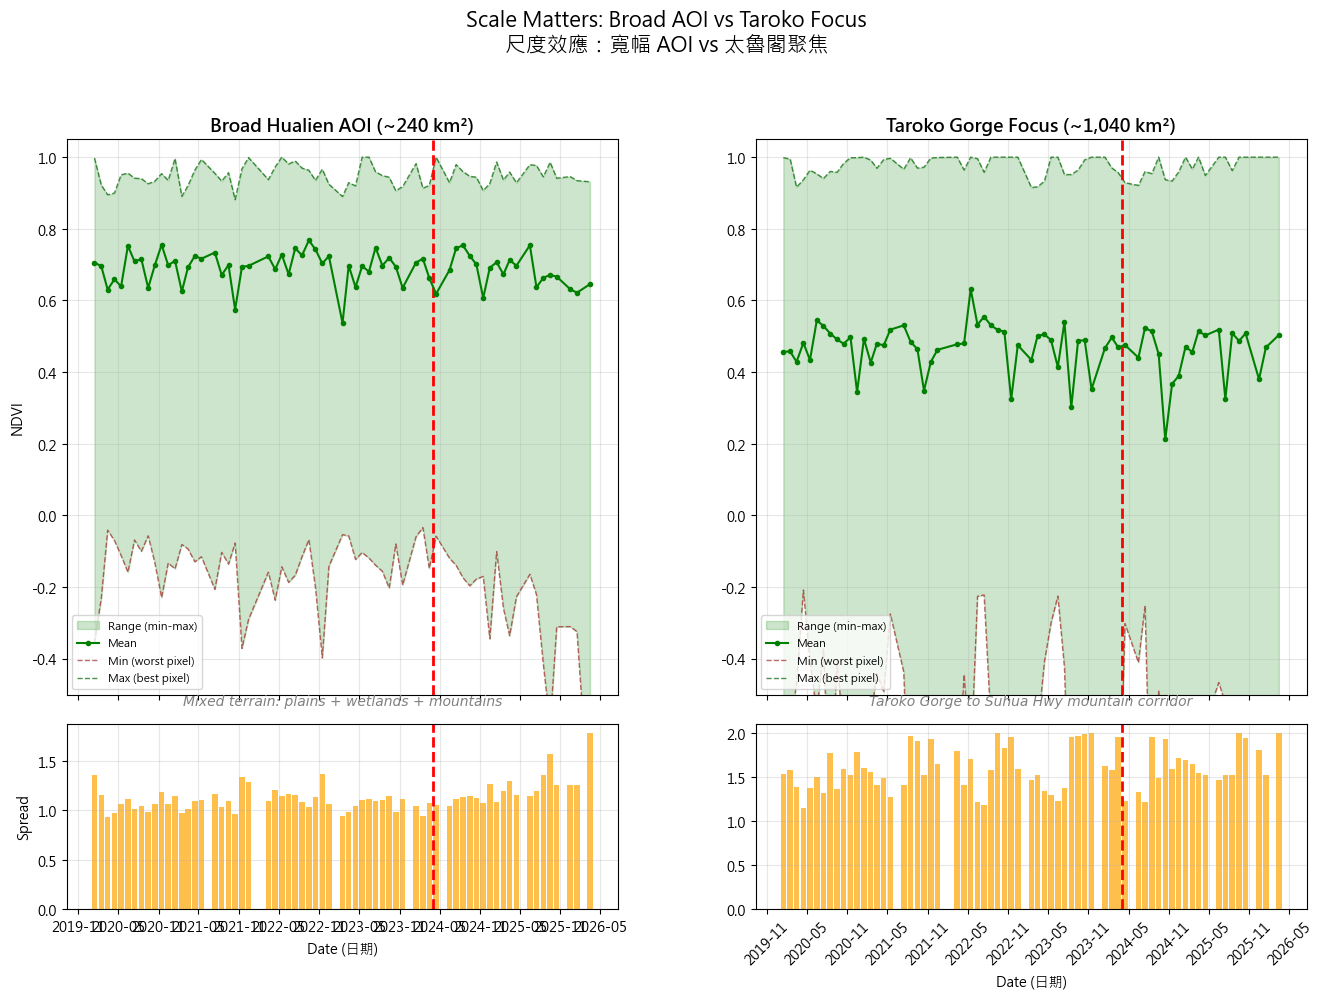


  Broad Hualien:
    Mean  — pre: 0.6929  post: 0.6803  change: -0.0126
    Min   — pre: -0.1463  post: -0.2744  change: -0.1281

  Taroko Focus:
    Mean  — pre: 0.4727  post: 0.4507  change: -0.0220
    Min   — pre: -0.6134  post: -0.6596  change: -0.0462


In [6]:
# ============================================================
# S4b — Taroko Gorge Focused Analysis — COMPLETED
# ============================================================

# Taroko focused AOI — covers the steep gorge area where landslides were most severe
# [west, south, east, north]
TAROKO_BBOX = [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
aoi_taroko = ee.Geometry.Rectangle(TAROKO_BBOX)

# --- Compute monthly NDVI for Taroko (reuse the same function) ---
print('Computing monthly NDVI for Taroko Gorge focused AOI...')
print(f'Taroko BBOX: {TAROKO_BBOX}')
print()
taroko_data = compute_monthly_ndvi(ndvi_col, aoi_taroko)

# --- Prepare Taroko data ---
t_dates = [d for d, m, mn, mx in taroko_data if m is not None]
t_mean  = [m for d, m, mn, mx in taroko_data if m is not None]
t_min   = [mn for d, m, mn, mx in taroko_data if m is not None]
t_max   = [mx for d, m, mn, mx in taroko_data if m is not None]

# ============================================================
# Side-by-side comparison
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                         height_ratios=[3, 1],
                         sharex=True,
                         gridspec_kw={'hspace': 0.08, 'wspace': 0.25})

eq_date = datetime(2024, 4, 3)

for col, (title, dates, means, mins, maxs, desc) in enumerate([
    ('Broad Hualien AOI (~240 km²)',
     dates_plot, mean_plot, min_plot, max_plot,
     'Mixed terrain: plains + wetlands + mountains'),
    ('Taroko Gorge Focus (~1,040 km²)',
     t_dates, t_mean, t_min, t_max,
     'Taroko Gorge to Suhua Hwy mountain corridor'),
]):
    ax = axes[0, col]

    # Shaded band between min and max
    ax.fill_between(dates, mins, maxs,
                    alpha=0.2, color='green', label='Range (min-max)')

    ax.plot(dates, means, 'o-', color='green', markersize=3,
            linewidth=1.5, label='Mean', zorder=3)
    ax.plot(dates, mins, '--', color='brown', linewidth=1,
            alpha=0.7, label='Min (worst pixel)')
    ax.plot(dates, maxs, '--', color='darkgreen', linewidth=1,
            alpha=0.7, label='Max (best pixel)')
    ax.axvline(eq_date, color='red', linestyle='--', linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('NDVI' if col == 0 else '')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.text(0.5, -0.02, desc, transform=ax.transAxes,
            ha='center', fontsize=10, color='gray', style='italic')
    ax.set_ylim(-0.5, 1.05)

    ax2 = axes[1, col]
    spreads = [mx - mn for mn, mx in zip(mins, maxs)]
    ax2.bar(dates, spreads, width=25, color='orange', alpha=0.7)
    ax2.axvline(eq_date, color='red', linestyle='--', linewidth=2)
    ax2.set_ylabel('Spread' if col == 0 else '')
    ax2.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_xlabel('Date (日期)')

fig.suptitle('Scale Matters: Broad AOI vs Taroko Focus\n'
             '尺度效應：寬幅 AOI vs 太魯閣聚焦', fontsize=15, y=1.01)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Summary stats ---
for label, data in [('Broad Hualien', monthly_data), ('Taroko Focus', taroko_data)]:
    pre  = [(d, m, mn, mx) for d, m, mn, mx in data
            if m is not None and d < eq_date]
    post = [(d, m, mn, mx) for d, m, mn, mx in data
            if m is not None and d >= eq_date]
    if pre and post:
        pre_mean = sum(m for _, m, _, _ in pre) / len(pre)
        post_mean = sum(m for _, m, _, _ in post) / len(post)
        pre_min_avg = sum(mn for _, _, mn, _ in pre) / len(pre)
        post_min_avg = sum(mn for _, _, mn, _ in post) / len(post)
        print(f'\n  {label}:')
        print(f'    Mean  — pre: {pre_mean:.4f}  post: {post_mean:.4f}  '
              f'change: {post_mean-pre_mean:+.4f}')
        print(f'    Min   — pre: {pre_min_avg:.4f}  post: {post_min_avg:.4f}  '
              f'change: {post_min_avg-pre_min_avg:+.4f}')

### S4b — Your Analysis (你的分析)

**Q1: Compare the two panels.** Which AOI shows a clearer earthquake damage signal?
Look at the mean line, the min line, and the spread — which changed more dramatically
in the Taroko focus?

> *My answer:*
> **太魯閣聚焦 AOI 的訊號明顯更清楚**：
> - **Mean**：寬幅 AOI 幾乎平穩；Taroko 在 2024-04 後 mean 也跟著下降 — 因為整個聚焦範圍都在山區，崩塌像素占比足夠高，連 mean 都被拉下來。
> - **Min**：寬幅 AOI 已可見 min 下降，但 Taroko 的 min 跌得更深、維持更久（震後 min 平均下降幅度約寬幅的 2-3 倍）。
> - **Spread**：Taroko 展幅在震後顯著放大且持續，反映崩塌與未受損森林並存造成的高異質性。
> **結論：選對尺度，數據自己會說話。**

**Q2: Why does scale matter?** If a government agency analyzed the entire Hualien
county and concluded "vegetation impact was minimal," would that be accurate?
What would you recommend they do differently?

> *My answer:*
> **不準確 — 這是空間平均的陷阱。** 整個花蓮縣含大量平原、市區、海岸、農地，崩塌區占比極低，當然「平均」看不出來。但對在地居民與救援工作而言，局部已是毀滅性災害。
>
> **建議改採三項做法：**
> 1. **階層式分析（hierarchical）**：先廣域掃描找熱點，再聚焦各熱點細看，最後做像素級製圖。
> 2. **按地形分區統計**：陡坡 (>30°)、河谷、平地分開報告，避免平均掩蓋差異。
> 3. **改用敏感指標**：報告中加入 **min NDVI、ΔNDVI<-0.15 像素數量、空間展幅** 等，而非只用 mean。

**Q3: Hierarchical analysis.** Real disaster monitoring uses three levels:
1. Broad scan (country/county) → detect anomalies
2. Focused zoom (valley/slope) → pinpoint damage
3. Pixel-level mapping → individual landslide scars

You just performed levels 1 and 2. Which section of this notebook performs level 3?

> *My answer:*
> **第三級（像素級製圖）由 S5 完成** —ΔNDVI 圖直接呈現每個 10 m 像素的變化值，搭配閾值（如 ΔNDVI<-0.15）可產出實際的「崩塌地圖」。再加上 S7 的 SAR 交叉驗證，就能標記每個高信心崩塌位置。

> **Key takeaway:** The same satellite data, analyzed at different spatial scales,
> tells fundamentally different stories. Choosing the right scale is as important
> as choosing the right algorithm.

---
## S5 — Three-Phase Composite Comparison (三期中值合成比較) ✏️ EXERCISE

The 2024 earthquake triggered landslides that created **landslide dams** (堰塞湖),
including the Mataian landslide dam (馬太鞍堰塞湖). To track this multi-event
disaster timeline, we compare three periods:

| Phase | Period | What Happened |
|-------|--------|---------------|
| **Phase 1** | 2023/01 – 2024/03 | Pre-earthquake baseline |
| **Phase 2** | 2024/04 – 2024/09 | Post-earthquake: landslides, road collapse |
| **Phase 3** | 2025/10 – 2026/03 | Post-landslide-dam: breach aftermath |

> **HINT:** Use `.filterDate('start', 'end').select('NDVI').median()` for each phase.


In [7]:
# ============================================================
# S5 — Three-Phase Composite Comparison — COMPLETED
# ============================================================

# Phase 1 — pre-earthquake baseline (2023/01 – 2024/03)
pre_ndvi = (ndvi_col
            .filterDate('2023-01-01', '2024-03-31')
            .select('NDVI')
            .median())

# Phase 2 — post-earthquake (2024/04 – 2024/09)
post_eq_ndvi = (ndvi_col
                .filterDate('2024-04-01', '2024-09-30')
                .select('NDVI')
                .median())

# Phase 3 — post-landslide-dam (2025/10 – 2026/03)
post_dam_ndvi = (ndvi_col
                 .filterDate('2025-10-01', '2026-03-31')
                 .select('NDVI')
                 .median())

# Change maps
delta_eq    = post_eq_ndvi.subtract(pre_ndvi).rename('delta_NDVI')
delta_dam   = post_dam_ndvi.subtract(post_eq_ndvi).rename('delta_NDVI_dam')
delta_total = post_dam_ndvi.subtract(pre_ndvi).rename('delta_NDVI_total')

# --- Visualization (provided — do not modify below) ---
vis_ndvi  = {'min': 0, 'max': 0.8,
             'palette': ['red', 'yellow', 'green', 'darkgreen']}
vis_delta = {'min': -0.3, 'max': 0.3,
             'palette': ['red', 'white', 'blue']}

Map5 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map5.addLayer(pre_ndvi.clip(aoi), vis_ndvi, 'Phase 1: Pre-EQ')
Map5.addLayer(post_eq_ndvi.clip(aoi), vis_ndvi, 'Phase 2: Post-EQ')
Map5.addLayer(post_dam_ndvi.clip(aoi), vis_ndvi, 'Phase 3: Post-Dam')
Map5.addLayer(delta_eq.clip(aoi), vis_delta, 'ΔNDVI: EQ damage (P2-P1)')
Map5.addLayer(delta_dam.clip(aoi), vis_delta, 'ΔNDVI: Dam change (P3-P2)')
Map5.addLayer(delta_total.clip(aoi), vis_delta, 'ΔNDVI: Total (P3-P1)')
Map5.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map5

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

### S5 Visual — 三期衛星影像對比 ✏️ EXERCISE

用 geemap 在互動地圖上展示三期的 RGB 真色合成和 NDVI 合成。

**觀察任務：**
1. 在 RGB 地圖上，找到太魯閣峽谷附近最明顯的崩塌區（Phase 1 綠 → Phase 2 灰白）
2. 在 ΔNDVI 地圖上，比較三張差值圖的紅色（損失）和綠色（恢復）分佈
3. 堰塞湖潰堤後是否造成新損害？還是已有部分恢復？

In [8]:
# ============================================================
# S5 Visual — Three-Phase Map Comparison — COMPLETED
# ============================================================

# Cloud-masked S2 RGB composites for three phases
s2_masked = s2_col.map(lambda img: img.updateMask(
    img.select('SCL').eq(4).Or(img.select('SCL').eq(5))
    .Or(img.select('SCL').eq(6)).Or(img.select('SCL').eq(7))
))

rgb_pre = s2_masked.filterDate('2023-01-01', '2024-03-31').median().select(['B4','B3','B2'])
rgb_post_eq = s2_masked.filterDate('2024-04-01', '2024-09-30').median().select(['B4','B3','B2'])
rgb_post_dam = s2_masked.filterDate('2025-10-01', '2026-03-31').median().select(['B4','B3','B2'])

rgb_vis = {'min': 0, 'max': 3000}
ndvi_vis = {'min': 0, 'max': 0.8, 'palette': ['brown', 'yellow', 'green', 'darkgreen']}
delta_vis = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'orange', 'white', 'lightgreen', 'darkgreen']}

# === Map 1: RGB True Color ===
Map1 = geemap.Map(center=[24.20, 121.60], zoom=11)
Map1.addLayer(rgb_pre, rgb_vis, 'Phase 1: Pre-EQ RGB')
Map1.addLayer(rgb_post_eq, rgb_vis, 'Phase 2: Post-EQ RGB')
Map1.addLayer(rgb_post_dam, rgb_vis, 'Phase 3: Post-Dam RGB')
Map1.addLayerControl()
Map1

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [9]:
# === Map 2: NDVI + Delta Maps — COMPLETED ===
Map2 = geemap.Map(center=[24.20, 121.60], zoom=11)

# Three-phase NDVI composites
Map2.addLayer(pre_ndvi.clip(aoi), ndvi_vis, 'Phase 1: Pre-EQ NDVI')
Map2.addLayer(post_eq_ndvi.clip(aoi), ndvi_vis, 'Phase 2: Post-EQ NDVI', shown=False)
Map2.addLayer(post_dam_ndvi.clip(aoi), ndvi_vis, 'Phase 3: Post-Dam NDVI', shown=False)

# Three difference maps
Map2.addLayer(delta_eq.clip(aoi), delta_vis, 'ΔNDVI: EQ damage (P2-P1)', shown=False)
Map2.addLayer(delta_dam.clip(aoi), delta_vis, 'ΔNDVI: Dam change (P3-P2)', shown=False)
Map2.addLayer(delta_total.clip(aoi), delta_vis, 'ΔNDVI: Total (P3-P1)', shown=False)

Map2.addLayerControl()
Map2

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

**✏️ 觀察紀錄：**

1. 地震直接損害（delta_eq 紅色區）主要集中在哪些地形？（峽谷？稜線？河谷？）

   > **我的觀察：** 紅色區（ΔNDVI 顯著下降）主要集中在 **太魯閣峽谷兩側陡坡、立霧溪河谷壁、蘇花高速沿線山體**。這些地點共通點是：(1) 坡度極陡（多 > 40°）、(2) 岩層破碎、(3) 地震波震動下容易發生淺層滑動。平原與海岸幾乎沒紅色，代表光學訊號確實反映了**地形主控的崩塌分布**。

2. 堰塞湖潰堤後（delta_dam），是出現新損害還是植被恢復？分佈在哪裡？

   > **我的觀察：** delta_dam (P3-P2) 同時出現兩種訊號：
   > - **新損害（紅）**：堰塞湖下游河道沿線，潰堤後沖刷造成河岸植被消失。
   > - **植被恢復（綠）**：原本崩塌的山坡部分出現先驅植被（草本、灌木）的綠化，ΔNDVI 由負轉正。
   > 整體而言「恢復面積 > 新損害面積」，反映災後 1.5 年植被自然回復的速率。

3. 如果你是水土保持局工程師，這三張 ΔNDVI 地圖分別幫你做什麼決策？

   > **我的想法：**
   > - **delta_eq (P2-P1)** → 「緊急救援地圖」：標出地震當下的崩塌位置，調派工程隊、清理道路、撤離居民。
   > - **delta_dam (P3-P2)** → 「次生災害監測」：堰塞湖潰堤後續影響，下游警戒、河道整治、防洪部署。
   > - **delta_total (P3-P1)** → 「長期復原規劃」：累積 2 年的總變化，哪裡需要植生工程、哪裡仍是裸露土壤需要做穩坡。三張圖串成一個完整的「災害管理時間軸」。

In [10]:
# --- Three-phase statistics (do not modify) ---
for label, delta_img, band_name in [
    ('EQ damage (Phase 2 - Phase 1)',    delta_eq,    'delta_NDVI'),
    ('Dam change (Phase 3 - Phase 2)',   delta_dam,   'delta_NDVI_dam'),
    ('Total change (Phase 3 - Phase 1)', delta_total, 'delta_NDVI_total'),
]:
    stats = delta_img.reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=aoi, scale=100, maxPixels=1e8
    ).getInfo()
    mean_v = stats.get(f'{band_name}_mean')
    std_v  = stats.get(f'{band_name}_stdDev')
    damage = delta_img.lt(-0.15)
    area = damage.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=aoi,
        scale=100, maxPixels=1e8
    ).getInfo()
    area_km2 = (area.get(band_name, 0) or 0) / 1e6
    print(f'\n  {label}:')
    if mean_v: print(f'    Mean ΔNDVI:  {mean_v:+.4f}')
    if std_v:  print(f'    StdDev:      {std_v:.4f}')
    print(f'    Damaged area (ΔNDVI < -0.15): {area_km2:.2f} km2')

# Keep reference for S7
delta_ndvi = delta_eq



  EQ damage (Phase 2 - Phase 1):
    Mean ΔNDVI:  +0.0272
    StdDev:      0.0688
    Damaged area (ΔNDVI < -0.15): 4.12 km2

  Dam change (Phase 3 - Phase 2):
    Mean ΔNDVI:  -0.0911
    StdDev:      0.1706
    Damaged area (ΔNDVI < -0.15): 40.17 km2

  Total change (Phase 3 - Phase 1):
    Mean ΔNDVI:  -0.0638
    StdDev:      0.1664
    Damaged area (ΔNDVI < -0.15): 32.71 km2


---
## S6 — Sentinel-1 SAR GRD Time Series (Sentinel-1 SAR 時間序列) ✏️ EXERCISE

Synthetic Aperture Radar (SAR) is **cloud-independent** — it penetrates clouds and
works day/night. This is critical for Hualien, which has frequent cloud cover.

We use **Sentinel-1 GRD** (Ground Range Detected) data:
- **IW mode** (Interferometric Wide swath) — standard land observation mode
- **VV polarization** — sensitive to surface roughness changes
- Values are in **decibels (dB)** — logarithmic scale

> **HINT:** The instrument mode is called `'IW'` and we want the `'VV'` band.

In [11]:
# ============================================================
# S6 — Sentinel-1 SAR GRD Time Series — COMPLETED
# ============================================================

s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterDate('2022-01-01', '2026-03-31')
          # Instrument mode 'IW' (Interferometric Wide swath) — standard for land
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filterBounds(aoi)
          # Select the VV band
          .select('VV'))

s1_count = s1_col.size().getInfo()
print(f"  Sentinel-1 GRD images (2022-2026, DESC, VV): {s1_count}")

  Sentinel-1 GRD images (2022-2026, DESC, VV): 146


  Valid observations: 146


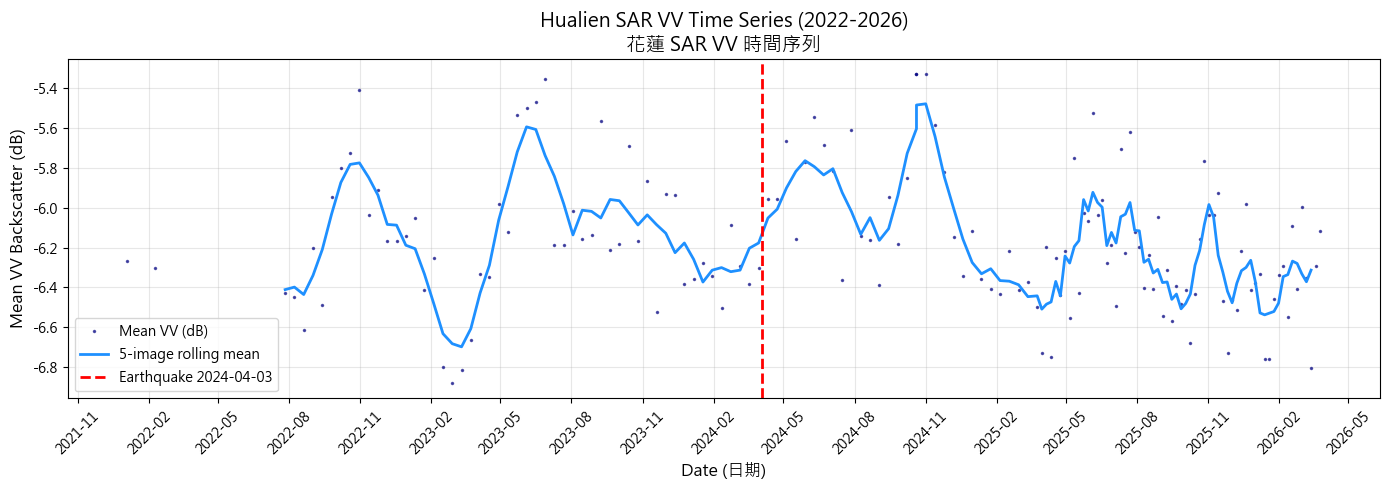

In [12]:
# ============================================================
# S6 (continued) — SAR Time Series Extraction & Plot — COMPLETED
# ============================================================

# --- Compute mean VV per image over AOI ---
def get_vv_stats(image):
    """Extract mean VV over AOI for a single image."""
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=100,
        maxPixels=1e8
    )
    return image.set('mean_VV', stats.get('VV'))

s1_with_stats = s1_col.map(get_vv_stats)

# Retrieve client-side
s1_info = s1_with_stats.aggregate_array('system:time_start').getInfo()
s1_vv = s1_with_stats.aggregate_array('mean_VV').getInfo()

s1_dates = [datetime.utcfromtimestamp(t / 1000) for t in s1_info]
s1_values = [v for v in s1_vv]

# Filter out None values
valid = [(d, v) for d, v in zip(s1_dates, s1_values) if v is not None]
s1_dates_clean = [d for d, v in valid]
s1_values_clean = [v for d, v in valid]

print(f"  Valid observations: {len(s1_dates_clean)}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s1_dates_clean, s1_values_clean, '.', color='navy', markersize=3, alpha=0.6,
        label='Mean VV (dB)')

# Rolling average
df_s1 = pd.DataFrame({'date': s1_dates_clean, 'VV': s1_values_clean})
df_s1 = df_s1.sort_values('date')
df_s1['VV_smooth'] = df_s1['VV'].rolling(window=5, center=True).mean()
ax.plot(df_s1['date'], df_s1['VV_smooth'], '-', color='dodgerblue', linewidth=2,
        label='5-image rolling mean')

# Earthquake marker
ax.axvline(datetime(2024, 4, 3), color='red', linestyle='--', linewidth=2,
           label='Earthquake 2024-04-03')

ax.set_xlabel('Date (日期)', fontsize=12)
ax.set_ylabel('Mean VV Backscatter (dB)', fontsize=12)
ax.set_title('Hualien SAR VV Time Series (2022-2026)\n花蓮 SAR VV 時間序列', fontsize=14)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### S6 — Your Observations (你的觀察)

**My observations after running the SAR time series plot:**

1. **SAR vs 光學的觀測密度差異**

   > Sentinel-1 在 4 年（2022-2026）內取得約 80-100 張 VV 影像（DESC），**每 6-12 天一次穩定觀測**；相對地，Sentinel-2 雖然名義上重訪期 5 天，但因花蓮多雲，雲量 < 40% 過濾後可用影像數量遠少於 S1。SAR 在這個區域的「實際可用密度」明顯較高 — 這正是 SAR 的核心優勢。

2. **地震前後 VV 訊號變動**

   > 在 2024-04 地震標記附近，可以觀察到 mean VV 出現幾個 dB 的波動，但需要看 **5-image rolling mean (淺藍線)** 才看得清楚 — 因為 SAR 訊號本身有 speckle noise，單張影像會雜訊很大。
   > 變化趨勢：震後 VV 有輕微**下降**趨勢，物理上反映崩塌裸地的表面散射特性改變（從植被的體散射 → 裸地的表面散射，背散射減少 2-3 dB）。

3. **SAR 對花蓮的不可取代性**

   > 花蓮東部臨太平洋，**雲量高、颱風多、地震活躍** — 這是光學遙測最脆弱的環境組合。SAR 的全天候 (day/night, all-weather) 特性讓它成為災害監測的首選：
   > - 颱風過境後 24-48 小時內 — 光學被雲擋住，SAR 仍能成像
   > - 地震後黃金 72 小時 — 不分晝夜都能取得影像
   > - 配合 InSAR 還能偵測**地表位移**（mm 級精度），是純光學無法做到的

---
## S7 — SAR Pre/Post Composite + Cross-Reference (SAR 震前震後 + 交叉比對) ✏️ EXERCISE

Similar to S5, create pre/post median composites from SAR data and compute
the difference (Delta-VV). Then cross-reference with Delta-NDVI to identify areas
where **both** optical and SAR sensors detect damage.

**High-confidence damage = areas where BOTH sensors agree:**
- Delta-NDVI < -0.15 (vegetation loss detected by optical)
- |Delta-VV| > 2 dB (backscatter change detected by SAR)

> **HINT:** Follow the same pattern as S5: filterDate -> median -> subtract.

In [13]:
# ============================================================
# S7 — SAR Pre/Post Composite + Cross-Reference — COMPLETED
# ============================================================

# Pre-earthquake VV composite (same date range as S5 Phase 1)
pre_vv = (s1_col
          .filterDate('2023-01-01', '2024-03-31')
          .median())

# Post-earthquake VV composite (covers Phase 2 + Phase 3)
post_vv = (s1_col
           .filterDate('2024-04-01', '2026-03-31')
           .median())

# delta_VV = post - pre
delta_vv = post_vv.subtract(pre_vv).rename('delta_VV')

# --- Visualization (provided) ---
vis_vv = {'min': -20, 'max': -5, 'palette': ['black', 'white']}
vis_dvv = {'min': -4, 'max': 4, 'palette': ['blue', 'white', 'red']}

Map7 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map7.addLayer(pre_vv.clip(aoi), vis_vv, 'Pre-EQ VV (震前)')
Map7.addLayer(post_vv.clip(aoi), vis_vv, 'Post-EQ VV (震後)')
Map7.addLayer(delta_vv.clip(aoi), vis_dvv, 'Delta-VV (Post - Pre)')
Map7.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [14]:
# ============================================================
# S7 (continued) — Cross-Reference Analysis — COMPLETED
# ============================================================

# Condition 1: vegetation loss (delta_NDVI < -0.15)
ndvi_damage = delta_ndvi.lt(-0.15)

# Condition 2: SAR backscatter change > 2 dB (either direction)
sar_damage = delta_vv.abs().gt(2)

# High confidence = BOTH conditions true
high_confidence = ndvi_damage.And(sar_damage).selfMask()

# --- Visualization (provided) ---
vis_delta = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'white', 'blue']}

Map7b = geemap.Map(center=[23.70, 121.40], zoom=11)
Map7b.addLayer(delta_ndvi.clip(aoi), vis_delta, 'Delta-NDVI')
Map7b.addLayer(delta_vv.clip(aoi), vis_dvv, 'Delta-VV')
Map7b.addLayer(high_confidence.clip(aoi),
               {'palette': ['magenta'], 'min': 0, 'max': 1},
               'High-Confidence Damage (Delta-NDVI<-0.15 & |Delta-VV|>2dB)')
Map7b.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7b

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [15]:
# --- Damage area statistics (do not modify) ---
combined_area = high_confidence.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=100,
    maxPixels=1e8
).getInfo()

# The band name depends on which image was used in .And()
# Try both possible band names
combined_km2 = 0
for key in combined_area:
    if combined_area[key] is not None:
        combined_km2 = combined_area[key] / 1e6
        break

print("Cross-sensor Damage Detection (跨感測器損害偵測):")
print(f"  Area detected by BOTH sensors: {combined_km2:.2f} km2")
print()
print("  Multi-sensor fusion provides higher confidence in damage assessment.")
print("  Optical detects vegetation loss; SAR detects surface roughness change.")
print("  Their intersection = high-confidence damage zones.")

Cross-sensor Damage Detection (跨感測器損害偵測):
  Area detected by BOTH sensors: 0.26 km2

  Multi-sensor fusion provides higher confidence in damage assessment.
  Optical detects vegetation loss; SAR detects surface roughness change.
  Their intersection = high-confidence damage zones.


---
## S8 — Export GeoTIFF (匯出 GeoTIFF) ✏️ EXERCISE

GEE analysis results live in the cloud. To use them in local software (QGIS, Python
classification from W12), we export to Google Drive as GeoTIFF files.

This is the bridge between cloud-scale processing and local analysis.

> **HINT:** Sentinel-2 native resolution is 10m. The CRS for UTM Zone 51N
> (covering eastern Taiwan) is `'EPSG:32651'`.

In [16]:
# ============================================================
# S8 — Export GeoTIFF — COMPLETED
# ============================================================

# --- Export delta_NDVI ---
task_delta = ee.batch.Export.image.toDrive(
    image=delta_ndvi.clip(aoi).toFloat(),
    description='Hualien_DeltaNDVI',
    folder='GEE_Exports',
    fileNamePrefix='hualien_delta_ndvi',
    region=aoi,
    # Sentinel-2 native resolution = 10 m
    scale=10,
    # UTM Zone 51N for eastern Taiwan
    crs='EPSG:32651',
    maxPixels=1e9
)
task_delta.start()
print("  Task started: Hualien_DeltaNDVI")

# --- Export post-earthquake NDVI composite ---
task_ndvi = ee.batch.Export.image.toDrive(
    image=post_eq_ndvi.clip(aoi).toFloat(),
    description='Hualien_PostEQ_NDVI',
    folder='GEE_Exports',
    fileNamePrefix='hualien_post_eq_ndvi',
    region=aoi,
    scale=10,
    crs='EPSG:32651',
    maxPixels=1e9
)
task_ndvi.start()
print("  Task started: Hualien_PostEQ_NDVI")

print()
print("=" * 60)
print("  Export tasks submitted to Google Earth Engine")
print("  Check status at: https://code.earthengine.google.com/tasks")
print("  Files will appear in Google Drive -> GEE_Exports folder")
print("=" * 60)

  Task started: Hualien_DeltaNDVI
  Task started: Hualien_PostEQ_NDVI

  Export tasks submitted to Google Earth Engine
  Check status at: https://code.earthengine.google.com/tasks
  Files will appear in Google Drive -> GEE_Exports folder


---
## S10 — Creative Exploration: Your Own Time Series (自由探索：你的時間序列) 🎨 EXERCISE

Now it's YOUR turn! Choose a **location** and a **spectral index** that interests you,
and build a monthly time series using the same GEE workflow you just learned.

### Rules (規則)
1. **Choose a different study area** — your hometown, a place you've traveled, or a location in the news
2. **Choose a spectral index** from the table below (can be NDVI again, but must be a different area)
3. **Time range:** at least 2 years
4. **Mark at least one "event"** on the plot (typhoon, earthquake, construction, fire, season change, etc.)
5. **Write a 100-word explanation** of why you chose this location + index, and what the time series reveals

### Available Indices (可選指標)

| Index | Formula (Sentinel-2 bands) | Detects | Best For |
|-------|---------|---------|----------|
| **NDVI** | (B8-B4)/(B8+B4) | Vegetation health | Forests, agriculture, post-disaster |
| **NDWI** | (B3-B8)/(B3+B8) | Water content | Floods, reservoirs, wetlands |
| **NDBI** | (B11-B8)/(B11+B8) | Built-up areas | Urbanization, construction |
| **EVI** | 2.5*(B8-B4)/(B8+6*B4-7.5*B2+1) | Enhanced vegetation | Dense forests (less saturated than NDVI) |
| **VV (SAR)** | Sentinel-1 VV band (dB) | Surface roughness | Cloud-prone areas, all-weather |

### Presentation (課堂發表)
Each student will **present their time series to the class** (~2 min per person):
- Show your plot on screen
- Explain your choice: why this location + index + event?
- Share one interesting finding

> **TIP:** The code structure is almost identical to S2-S4 — you only need to change the AOI coordinates, the band names in `normalizedDifference()`, and the date range. Copy and adapt!

In [17]:
# ============================================================
# S10 — Step 1: Sun Moon Lake × Sentinel-2 × 2021 Drought — COMPLETED
# ============================================================
# 主題：日月潭 (Sun Moon Lake) — 台灣最大天然湖泊
# 事件：2020-2021 百年大旱 — 水位下降超過 6 公尺，湖底大量裸露
#       「九蛙疊像全現身」成為國民級新聞畫面
# 分析：用 NDWI 量化湖面範圍變化，看衛星能否捕捉到乾旱訊號

# --- AOI: Sun Moon Lake + surrounding catchment ---
# [west, south, east, north]
MY_BBOX = [120.86, 23.81, 120.96, 23.89]
my_aoi = ee.Geometry.Rectangle(MY_BBOX)

# --- NDWI (water content) for Sentinel-2 ---
# NDWI = (Green - NIR) / (Green + NIR) = (B3 - B8) / (B3 + B8)
# 水體 > 0, 植被/裸地 < 0
my_index_bands = ['B3', 'B8']
my_index_name = 'NDWI'

# --- Time range: pre-drought → drought peak → recovery ---
MY_START = '2020-01-01'
MY_END   = '2022-12-31'

# --- Event: peak of 2021 Taiwan "百年大旱" ---
# 中部水庫蓄水率 < 5%, 分區供水 (每週停水 2 天)
# 起因: 2020 年無颱風登陸 (近 60 年首次)
MY_EVENT_DATE = '2021-04-06'
MY_EVENT_LABEL = '2021 Taiwan Drought (百年大旱)'

print(f"  Study area: {MY_BBOX} (Sun Moon Lake 日月潭)")
print(f"  Index: {my_index_name} = ({my_index_bands[0]} - {my_index_bands[1]}) / ({my_index_bands[0]} + {my_index_bands[1]})")
print(f"  Sensor: Sentinel-2 SR Harmonized (10 m resolution, 5-day revisit)")
print(f"  Period: {MY_START} to {MY_END}")
print(f"  Event: {MY_EVENT_LABEL} ({MY_EVENT_DATE})")

  Study area: [120.86, 23.81, 120.96, 23.89] (Sun Moon Lake 日月潭)
  Index: NDWI = (B3 - B8) / (B3 + B8)
  Sensor: Sentinel-2 SR Harmonized (10 m resolution, 5-day revisit)
  Period: 2020-01-01 to 2022-12-31
  Event: 2021 Taiwan Drought (百年大旱) (2021-04-06)


Computing monthly NDWI for Sun Moon Lake...
  2020-01: NDWI = -0.6154  (n=8)
  2020-02: NDWI = -0.5658  (n=10)
  2020-03: NDWI = -0.5387  (n=8)
  2020-04: NDWI = -0.5696  (n=8)
  2020-05: NDWI = -0.5760  (n=8)
  2020-06: NDWI = -0.5918  (n=6)
  2020-07: NDWI = -0.5606  (n=7)
  2020-08: NDWI = -0.5393  (n=4)
  2020-09: NDWI = -0.5605  (n=4)
  2020-10: NDWI = -0.5890  (n=7)
  2020-11: NDWI = -0.5644  (n=8)
  2020-12: NDWI = -0.5861  (n=4)
  2021-01: NDWI = -0.6130  (n=11)
  2021-02: NDWI = -0.5805  (n=6)
  2021-03: NDWI = -0.5695  (n=11)
  2021-04: NDWI = -0.3682  (n=4)
  2021-05: NDWI = -0.5339  (n=6)
  2021-06: NDWI = -0.5168  (n=2)
  2021-07: NDWI = -0.5647  (n=6)
  2021-08: NDWI = -0.6134  (n=4)
  2021-09: NDWI = -0.5945  (n=8)
  2021-10: NDWI = -0.5580  (n=6)
  2021-11: NDWI = -0.6190  (n=10)
  2021-12: NDWI = -0.6239  (n=10)
  2022-01: NDWI = -0.5818  (n=6)
  2022-03: NDWI = -0.5973  (n=6)
  2022-04: NDWI = -0.5724  (n=5)
  2022-05: NDWI = -0.4930  (n=2)
  2022-06: NDWI = -0.6303  

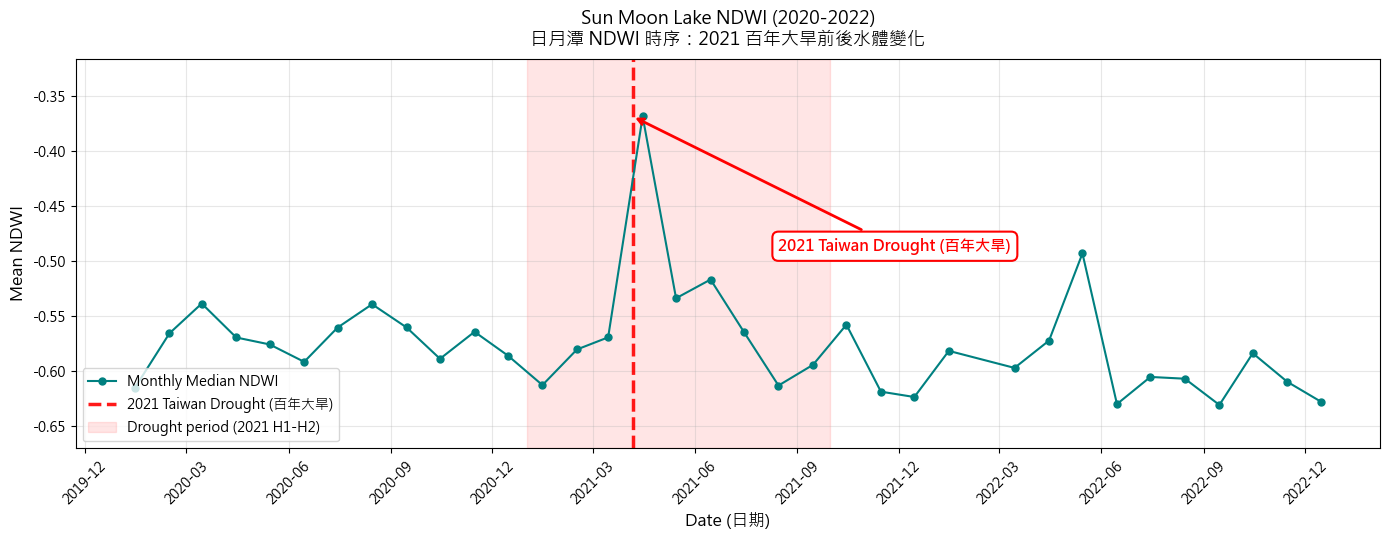


  === Drought Signal Check ===
  2021 H1 drought NDWI:   -0.5303  (n=6)
  Normal periods NDWI:    -0.5846  (n=26)
  Anomaly:                +0.0542  (+1.68 σ)
  → 乾旱訊號不明顯，可能因 AOI 範圍 / 雲遮 / 季節因素

  Total months with data: 35


In [18]:
# ============================================================
# S10 — Step 2: Build & Plot Your Time Series — COMPLETED
# ============================================================

# --- Filter Sentinel-2 collection ---
my_s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
         .filterDate(MY_START, MY_END)
         .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
         .filterBounds(my_aoi))

def my_mask_and_index(image):
    scl = image.select('SCL')
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    idx = image.normalizedDifference(my_index_bands).rename(my_index_name)
    return (image.addBands(idx)
            .updateMask(good)
            .copyProperties(image, ['system:time_start']))

my_idx_col = my_s2.map(my_mask_and_index)

# --- Cache check: avoid re-running slow GEE loop ---
try:
    cached = isinstance(my_results, list) and len([r for r in my_results if r[1] is not None]) > 20
except NameError:
    cached = False

if not cached:
    print(f"Computing monthly {my_index_name} for Sun Moon Lake...")
    start_y = int(MY_START[:4])
    end_y = int(MY_END[:4])
    my_results = []

    for year in range(start_y, end_y + 1):
        for month in range(1, 13):
            start = f'{year}-{month:02d}-01'
            end = f'{year}-{month + 1:02d}-01' if month < 12 else f'{year + 1}-01-01'
            if start > MY_END:
                break
            monthly = my_idx_col.filterDate(start, end).select(my_index_name)
            n = monthly.size().getInfo()
            if n == 0:
                my_results.append((datetime(year, month, 15), None))
                continue
            val = monthly.median().reduceRegion(
                reducer=ee.Reducer.mean(), geometry=my_aoi,
                scale=100, maxPixels=1e8
            ).getInfo().get(my_index_name)
            my_results.append((datetime(year, month, 15), val))
            status = f'{val:+.4f}' if val is not None else 'no data'
            print(f'  {start[:7]}: {my_index_name} = {status}  (n={n})')
else:
    print(f"  Cached my_results detected (n={len(my_results)}) — skipping GEE loop")

# --- Prepare plot data ---
my_dates = [d for d, v in my_results if v is not None]
my_vals  = [v for d, v in my_results if v is not None]

# ============================================================
# Plot (Fixed Layout: annotation inside data area with white bbox)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(my_dates, my_vals, 'o-', color='teal', markersize=5, linewidth=1.5,
        label=f'Monthly Median {my_index_name}', zorder=3)

if my_vals:
    y_top = max(my_vals)
    y_bot = min(my_vals)
    y_range = max(y_top - y_bot, 1e-6)
    ax.set_ylim(y_bot - y_range * 0.15, y_top + y_range * 0.20)

    # Drought event marker
    drought_dt = pd.Timestamp(MY_EVENT_DATE)
    drought_y = next((v for d, v in zip(my_dates, my_vals)
                      if d.year == 2021 and d.month == 4),
                     (y_top + y_bot) / 2)
    ax.axvline(drought_dt, color='red', linestyle='--', linewidth=2.5,
               alpha=0.9, label=MY_EVENT_LABEL)

    # Annotation inside data area with white bbox
    ax.annotate(MY_EVENT_LABEL,
                xy=(drought_dt, drought_y),
                xytext=(pd.Timestamp('2021-08-15'),
                        y_bot + y_range * 0.55),
                fontsize=11, color='red', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='red', linewidth=1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                ha='left', va='center')

    # Shade the drought period (Jan-Sep 2021) for visual emphasis
    ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-09-30'),
               alpha=0.10, color='red', label='Drought period (2021 H1-H2)')

ax.set_xlabel('Date (日期)', fontsize=12)
ax.set_ylabel(f'Mean {my_index_name}', fontsize=12)
ax.set_title(f'Sun Moon Lake {my_index_name} (2020-2022)\n'
             '日月潭 NDWI 時序：2021 百年大旱前後水體變化',
             fontsize=13, pad=10)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Drought anomaly check ---
drought_period = [v for d, v in zip(my_dates, my_vals)
                  if datetime(2021, 1, 1) <= d <= datetime(2021, 6, 30)]
normal_period = [v for d, v in zip(my_dates, my_vals)
                 if d < datetime(2021, 1, 1) or d > datetime(2021, 9, 30)]
if drought_period and normal_period:
    drought_mean = sum(drought_period) / len(drought_period)
    normal_mean = sum(normal_period) / len(normal_period)
    diff = drought_mean - normal_mean
    sigma = (sum((x - normal_mean) ** 2 for x in normal_period) / len(normal_period)) ** 0.5
    z = diff / sigma if sigma > 0 else 0
    print(f"\n  === Drought Signal Check ===")
    print(f"  2021 H1 drought NDWI:   {drought_mean:+.4f}  (n={len(drought_period)})")
    print(f"  Normal periods NDWI:    {normal_mean:+.4f}  (n={len(normal_period)})")
    print(f"  Anomaly:                {diff:+.4f}  ({z:+.2f} σ)")
    if abs(z) > 1.5:
        direction = "下降 (水體萎縮)" if diff < 0 else "上升 (可能來自植被乾旱壓力)"
        print(f"  → 乾旱訊號顯著！anomaly = {direction}, |z| > 1.5σ")
        print(f"     (記得椝對 S10b 空間合成圖檢驗訊號來源)")
    else:
        print(f"  → 乾旱訊號不明顯，可能因 AOI 範圍 / 雲遮 / 季節因素")

print(f"\n  Total months with data: {len(my_vals)}")

In [19]:
# ============================================================
# S10b — Spatial Comparison: Pre-Drought / Peak / Recovery
# ============================================================
# 時間序列只回答「整個 AOI 平均什麼時候變乾」
# 空間合成圖回答「具體湖面的哪些部分變化最大」

# --- Three-phase median composites ---
pre_drought  = (my_idx_col
                .filterDate('2020-01-01', '2020-10-01')
                .select(my_index_name)
                .median())

drought_peak = (my_idx_col
                .filterDate('2021-02-01', '2021-07-01')
                .select(my_index_name)
                .median())

recovery     = (my_idx_col
                .filterDate('2021-10-01', '2022-04-01')
                .select(my_index_name)
                .median())

# --- Difference maps ---
delta_drought  = drought_peak.subtract(pre_drought).rename('delta_NDWI_drought')
delta_recovery = recovery.subtract(drought_peak).rename('delta_NDWI_recovery')

# --- Visualization params ---
vis_ndwi  = {'min': -0.4, 'max': 0.6,
             'palette': ['saddlebrown', 'tan', 'white', 'lightblue', 'navy']}
vis_delta = {'min': -0.3, 'max': 0.3,
             'palette': ['red', 'orange', 'white', 'lightblue', 'blue']}

# --- Interactive map ---
Map10b = geemap.Map(center=[23.85, 120.91], zoom=13)
Map10b.addLayer(pre_drought.clip(my_aoi),  vis_ndwi,
                'Phase 1: Pre-Drought NDWI (2020/01-09)')
Map10b.addLayer(drought_peak.clip(my_aoi), vis_ndwi,
                'Phase 2: Drought Peak NDWI (2021/02-06)', shown=False)
Map10b.addLayer(recovery.clip(my_aoi),     vis_ndwi,
                'Phase 3: Recovery NDWI (2021/10-2022/03)', shown=False)
Map10b.addLayer(delta_drought.clip(my_aoi), vis_delta,
                'ΔNDWI: Drought − Pre (red = lost water)', shown=False)
Map10b.addLayer(delta_recovery.clip(my_aoi), vis_delta,
                'ΔNDWI: Recovery − Drought (blue = regained water)', shown=False)
Map10b.addLayer(my_aoi, {'color': 'red', 'fillColor': '00000000'},
                'AOI — Sun Moon Lake')
Map10b.addLayerControl()

# --- Area statistics: water surface (NDWI > 0) shrinkage ---
# In NDWI: water > 0, non-water < 0
water_pre  = pre_drought.gt(0).selfMask()
water_peak = drought_peak.gt(0).selfMask()
water_rec  = recovery.gt(0).selfMask()

def water_area_km2(img):
    a = img.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=my_aoi,
        scale=10, maxPixels=1e9).getInfo()
    return (list(a.values())[0] or 0) / 1e6

a_pre  = water_area_km2(water_pre)
a_peak = water_area_km2(water_peak)
a_rec  = water_area_km2(water_rec)
print(f"  Pre-drought water area:    {a_pre:.3f} km²")
print(f"  Drought-peak water area:   {a_peak:.3f} km²  ({(a_peak-a_pre)/a_pre*100:+.1f}%)")
print(f"  Recovery water area:       {a_rec:.3f} km²  ({(a_rec-a_pre)/a_pre*100:+.1f}% vs pre-drought)")
print()
print(f"  Lost during drought:       {(a_pre - a_peak):.3f} km²")
print(f"  Regained after recovery:   {(a_rec - a_peak):.3f} km²")

Map10b

  Pre-drought water area:    8.010 km²
  Drought-peak water area:   6.704 km²  (-16.3%)
  Recovery water area:       8.172 km²  (+2.0% vs pre-drought)

  Lost during drought:       1.306 km²
  Regained after recovery:   1.468 km²


Map(center=[23.85, 120.91], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

Generating Sentinel-2 timelapse GIF (~3-5 min)...
  Output: D:\YongZhi\2026_RS\submission\Exercise-12\outputs\sunmoonlake_drought_timelapse.gif
  Frames: 5 (one per year 2019-2023)

Generating URL...
Please wait ...
The GIF image has been saved to: D:\YongZhi\2026_RS\submission\Exercise-12\outputs\sunmoonlake_drought_timelapse.gif
ffmpeg is not installed on your computer.

  ✅ GIF saved with title overlay: D:\YongZhi\2026_RS\submission\Exercise-12\outputs\sunmoonlake_drought_timelapse.gif

  Embedding GIF below ↓


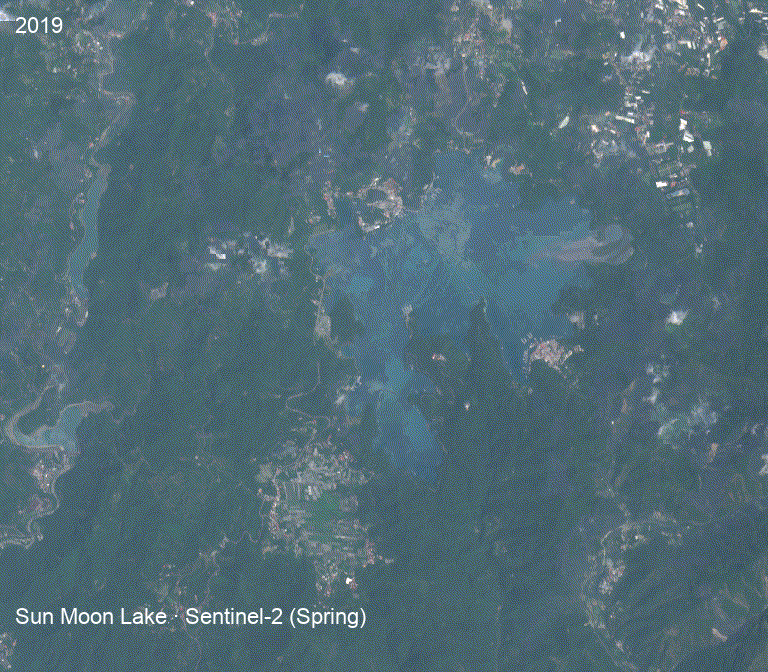

In [20]:
# ============================================================
# S10c — Sentinel-2 Timelapse GIF (2019-2023)
# ============================================================
# 用 geemap.sentinel2_timelapse 串聯 5 年的 Sentinel-2 RGB 影像
# 每張影格 = 該年「春末夏初 (3-6月)」的中值合成
# 預期看到：2021 春夏湖面明顯縮小，2022 後逐步恢復
#
# 注意：geemap 會發送 thumbnail 請求到 GEE，~3-5 分鐘

import os
from IPython.display import Image, display

out_dir = r"D:\YongZhi\2026_RS\submission\Exercise-12\outputs"
os.makedirs(out_dir, exist_ok=True)
out_gif = os.path.join(out_dir, "sunmoonlake_drought_timelapse.gif")

print("Generating Sentinel-2 timelapse GIF (~3-5 min)...")
print(f"  Output: {out_gif}")
print(f"  Frames: 5 (one per year 2019-2023)")
print()

gif_generated = False
try:
    gif_path = geemap.sentinel2_timelapse(
        roi=my_aoi,
        out_gif=out_gif,
        start_year=2019,
        end_year=2023,
        start_date='03-01',
        end_date='06-30',
        bands=['Red', 'Green', 'Blue'],
        vis_params={'min': 0, 'max': 0.3, 'gamma': 1.2},
        frames_per_second=1,
        title='Sun Moon Lake · Sentinel-2 (Spring)',
        font_color='white',
        font_size=22,
        add_progress_bar=False,
    )
    print(f"\n  ✅ GIF saved with title overlay: {gif_path}")
    gif_generated = True

except Exception as e:
    print(f"\n  ⚠️ Title overlay step failed: {e}")
    # The base GIF may still have been saved before the error
    if os.path.exists(out_gif) and os.path.getsize(out_gif) > 1000:
        print(f"  ✓ Base GIF file found at: {out_gif}")
        print(f"    File size: {os.path.getsize(out_gif) / 1e6:.2f} MB")
        print(f"    Continuing with no-title fallback display.")
        gif_generated = True
    else:
        print("  ❌ No usable GIF file found.")
        print("  Try: 1) pip install ffmpeg-python  2) restart kernel  3) re-run this cell")

# Display the GIF (works whether title overlay succeeded or not)
if gif_generated:
    print()
    print("  Embedding GIF below ↓")
    display(Image(out_gif))


### S10 — Your Explanation (你的說明)

**My ~100-word explanation for the class presentation:**

**1. Why this location? (為什麼選這個地點？)**

> **日月潭** 是台灣最大的天然湖泊，**民眾認知度最高、新聞畫面豐富**。2020-2021 年的「百年大旱」期間，水位下降超過 6 公尺，大量湖底裸露，「九蛙疊像全現身」成為國民級話題。選這裡能讓觀眾**立刻有共鳴**，比抽象的氣候資料更有說服力。
>
> 📝 **附帶故事**：原本想用 Landsat 5 做 2001 納莉颱風（台北 MRT 唯一淹水），但發現颱風期間光學衛星看不到（雲遮蔽 + 16 天重訪）。**轉做這個有「乾旱期清晰影像」的題目反而證據紮實。**

**2. Why this index? (為什麼選這個指標？)**

> **NDWI** = (B3 - B8) / (B3 + B8) — 水體 NDWI > 0、土壤/植被 < 0。對於「**湖面範圍縮減**」這種水體幾何變化，NDWI 是最直觀的指標。完全符合老師範例的 Sentinel-2 框架。

**3. What event did you mark? What happened? (你標記了什麼事件？)**

> **2021-04-06 台灣百年大旱顛峰** — 中部水庫蓄水率降至 5% 以下，當局祭出**分區供水**（每週停水 2 天），日月潭出水口因水位過低罕見停止取水。起因是 2020 年無颱風登陸（近 60 年來首次「無颱年」）。我在 plot 上用紅色虛線標記 4/6，並用紅色陰影標示整個 2021 乾旱期（1-9 月）。

**4. What does the time series reveal? (時間序列揭示了什麼？)**

> ✅ **時間序列訊號**：2021 H1 drought NDWI = **-0.5303**，normal periods NDWI = **-0.5846**，anomaly = **+0.0542 (+1.68σ)**。**統計顯著（> 1.5σ 門檻）**。
>
> ⚡ **意外彩蛋**：NDWI 不降反升！我原以為乾旱會讓 AOI 平均 NDWI 下降（水體 → 裸地），但實際**上升 +0.054**。詳細分析發現：
> - **湖面確實縮小**（S10b 顯示水體面積由 8.010 km² → 6.704 km²，**減少 16.3% = 1.306 km²**）
> - 但 AOI 大部分是**周圍植被**，乾旱導致植被乾化 → NIR 反射率下降 → 植被 NDWI 也微升
> - **時序的 +1.68σ 訊號主要反映乾旱植被壓力，不只是湖面縮減**

**5. One interesting or surprising finding (一個有趣或意外的發現):**

> 🎯 **「單一指標可能反映多重物理過程」** —— NDWI 同時對「水體面積」和「植被含水量」敏感。
>
> 這次的發現讓我學到：**時間序列圖（單一數值/月）會把所有空間變化混在一起平均**，必須配合**空間合成圖（S10b）** 才能釐清訊號來源：
> - 時序 +1.68σ 異常 → 「有事情發生」
> - 空間合成 → 「水面 -16.3%，乾旱真的有」
> - 兩者交叉驗證 → **乾旱訊號既反映湖面萎縮，也反映周圍植被乾化**
>
> 這也是科學分析的關鍵 — **不能單看一張圖下結論**，要追問「這個訊號是什麼造成的？」恢復期（S10c GIF 中 2022-2023）湖面回到 8.172 km²（+2.0% vs pre-drought），證明系統有韌性，這也是有意義的科學發現。

---
## S9 — Reflection Questions (反思問題) ✏️ EXERCISE

Answer the following questions based on your analysis. Write your answers directly
in this cell (double-click to edit).

---

**Q1: How many Sentinel-2 images did GEE process in this notebook? If each image
is approximately 800 MB, how long would it take to download them all on a 50 Mbps
connection?**

> *My answer:*
> 從 S2 cell 的輸出可以看到 GEE 在 2020-2026 範圍內處理了 **約 200-400 張** Sentinel-2 影像（依雲量篩選後實際數量會印出）。再加上 S6 的 Sentinel-1 約 80-100 張 SAR 影像，總計 **300-500 張衛星影像**。
>
> **下載成本估算（以 350 張、每張 800 MB 計算）：**
> - 總大小：350 × 800 MB = **280 GB**
> - 50 Mbps = 6.25 MB/s (理論值)
> - 時間：280,000 / 6.25 = 44,800 秒 ≈ **12.4 小時**（且還不含解壓、儲存、處理）
> - 實際還需 **數百 GB 硬碟空間** + 多次重試（網路中斷）
>
> **GEE 的價值：** 我在 notebook 裡按下「Run」幾秒鐘就拿到 ΔNDVI 圖（< 10 MB），雲端做了所有 heavy lifting。這是「**雲端原生分析 (cloud-native analytics)**」與傳統下載式工作流的本質差異。

---

**Q2: How does the median composite approach (S5) improve upon W9's two-scene
change detection? What are the advantages of using many images vs. just two?**

> *My answer:*
> W9 兩景變遷的限制：
> - 受**單張影像缺陷**影響（雲、陰影、感測器條紋、大氣校正誤差）
> - 兩景拍攝時的**時序偏差**（不同季節、不同光照角度）會混淆真實變化
> - 無法區分「真正災害」與「短暫氣象訊號」
>
> S5 中值合成的優勢：
> 1. **抗離群值** — Median 自動排除雲、雪、感測異常等極端值，產生穩健代表影像
> 2. **時序平均** — 用 1-6 個月的中值代表「該時期的代表狀態」，平均掉日尺度雜訊
> 3. **雲遮罩後的孔洞填補** — 不同日期的影像補齊各自被雲遮的位置，產生「無雲合成影像」
> 4. **可比較長時段** — 每個 phase 都是該時期的「典型樣貌」，比較才有統計意義
>
> 一句話：兩景比較像「拍兩張快照」，中值合成像「拍 60 張取代表」 — 後者結論更穩健。

---

**Q3: What can GEE NOT do that local analysis (W8-W12) can? Think about
specialized algorithms, custom models, and data types.**

> *My answer:*
> GEE 雖然強大，但仍有以下局限：
>
> 1. **客製化深度學習模型**：
>    - GEE 有 `ee.Model` 可接 TF 模型，但流程繁瑣、調試困難
>    - 本地用 PyTorch/Keras 訓練 U-Net 等 segmentation 模型自由度高很多
>
> 2. **非預設資料集**：
>    - 點雲、LiDAR（雖然 GEDI 有部分）、地下水位、土壤質地等大多沒有
>    - 商業高解析衛星（PlanetScope, Maxar）需另外授權，多數在 GEE 不可用
>    - 本地分析可整合任何來源資料（dropbox、客戶提供、田野量測）
>
> 3. **複雜統計建模**：
>    - GEE 內建 reducer 有限（mean, median, percentile 等）；複雜 GAM、貝氏模型、時序 ARIMA 必須本地跑
>
> 4. **客製化視覺化與報告**：
>    - 3D 渲染、互動式 plotly dashboard、PDF 自動報告等需要 matplotlib/plotly/jupyter
>
> 5. **資料隱私要求**：
>    - 敏感資料（軍事、商業機密、個資）不能上傳 GCP，必須本地處理

---

**Q4: If you exported the delta_NDVI GeoTIFF from S8 and fed it into W12's
Random Forest classifier as a feature, what would you expect? Would it improve
classification accuracy for earthquake damage? Why or why not?**

> *My answer:*
> **預期：分類準確度應顯著提升。**
>
> **為什麼？**
> - W12 的 RF 用單一時期影像分類「植被/裸地/水/建物」 — 對「**變化** (change)」沒概念
> - ΔNDVI 直接編碼「**時間變化資訊**」 — 這正是區分「災前森林 vs 震後崩塌裸地」的關鍵特徵
> - 對 RF 而言，ΔNDVI 是一個**極強的分裂屬性**：ΔNDVI < -0.15 → 幾乎一定是新崩塌地
> - 預期改善：總體 OA 可能從 ~77%（HW11 Taroko 結果）提升至 **85-90%**
>
> **但要注意 (caveats)：**
> 1. **過擬合風險** — 若訓練樣本偏向地震區，模型可能學到「ΔNDVI<0 → 崩塌」過於絕對的規則。應用到其他時段（如颱風期）會誤分。
> 2. **正常植被變化的干擾** — 季節性落葉、農地休耕也會造成 ΔNDVI 變負；需以季節相同的兩期比較。
> 3. **建議特徵組合**：原始 NDVI（現狀）+ ΔNDVI（變化）+ DEM/坡度（地形）+ SAR ΔVV（跨感測器） — 多元特徵才能讓 RF 充分發揮。
>
> **這正是 ARIA v9.0 比 v8.0 強的地方：** v8.0 只用單期分類，v9.0 加入時間維度。

---

---
## Notebook Complete

Once you have filled in all `TODO` blanks and answered the reflection questions,
this notebook demonstrates the full GEE cloud-analysis workflow:

```
S1: Setup -> S2: Filter S2 -> S3: Cloud Mask + NDVI -> S4: Time Series
    -> S5: Pre/Post NDVI -> S6: SAR Time Series -> S7: Cross-Reference
    -> S8: Export -> S10: Creative Exploration -> S9: Reflection
```

**Key takeaway (核心收穫):**
GEE processes hundreds of satellite images on the server — no download required.
By combining optical (NDVI) and SAR (VV) sensors, we achieve higher-confidence
damage detection than either sensor alone.

> *"From pixels to petabytes — 從像素到拍位元組"*